In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import yfinance as yf

import joblib
import os
import sys
import warnings
warnings.filterwarnings('ignore')
curr = os.getcwd()
sys.path.append(os.path.abspath(os.path.join(curr, '..')))
from features import FEATURES
from help_folder.backtest import backtest, production_backtest, filter_signals
from help_folder.help import prepare_data, stage1, stage2, calculate_base_features, optimize_threshold, generate_final_report, download, save_models, save_artifacts_json, print_stage_report

In [ ]:
# Параметры
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TICKER = "AAPL"
START_DATE = "2010-01-01"
END_DATE = "2023-12-31"
INTERVAL = "1d"

TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEQUENCE_LENGTH = 80

GRU_UNITS_1 = 64
GRU_UNITS_2 = 32
DENSE_UNITS = 16
DROPOUT_RATE = 0.5 
LEARNING_RATE = 0.0005  
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE_ES = 7
PATIENCE_LR = 5

MOVE_THRESHOLD = 0.015
HORIZON = 10

COMMISSION = 0.001
SLIPPAGE = 0.0005
MAX_POSITION_SIZE = 0.1 
MAX_DRAWDOWN = 0.15      

MODEL_PATH = '../models/model_gru'

In [3]:
def create_model(input_dim, name="model"):
    model = Sequential([
        Input(shape=input_dim),
        GaussianNoise(0.01), 
        GRU(GRU_UNITS_1, 
            return_sequences=True,
            kernel_regularizer=regularizers.l2(1e-4), 
            recurrent_dropout=0.1 
           ),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),
        
        GRU(GRU_UNITS_2, 
            return_sequences=False,
            kernel_regularizer=regularizers.l2(1e-4),
            recurrent_dropout=0.1
           ),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),
        Dense(DENSE_UNITS, 
              activation='relu',
              kernel_regularizer=regularizers.l2(1e-4)
             ),
        Dropout(0.2), 
        
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE), 
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [4]:
# ЗАГРУЗКА ДАННЫХ
raw_data, raw_df = download(TICKER, START_DATE, END_DATE, interval=INTERVAL)
print(f"📊 Загружено {len(raw_df)} записей")

spy = yf.download("SPY", start=START_DATE, end=END_DATE, progress=False)
vix = yf.download("^VIX", start=START_DATE, end=END_DATE, progress=False)

spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)

print("\n🔧 Подготовка данных...")
df = calculate_base_features(raw_df, spy, vix)
df = df.reset_index(drop=True)

# ПОДГОТОВКА ДАННЫХ
res_prepare_data = prepare_data(
    df, TRAIN_SPLIT, VAL_SPLIT, SEQUENCE_LENGTH,
    move_threshold=MOVE_THRESHOLD, horizon=HORIZON, FEATURES1=FEATURES
)

📊 Загружено 2768 записей

🔧 Подготовка данных...
✅ Создано 34 признаков. Всего строк: 2768
✅ Train: 1870 | Val: 354 | Test: 354


In [5]:
# STAGE 1: MOVE and HOLD
res_stage1 = stage1(
    res_prepare_data['X_train'], res_prepare_data['X_val'], res_prepare_data['X_test'],
    res_prepare_data['y1_train'], res_prepare_data['y1_val'], res_prepare_data['y1_test'], 
    res_prepare_data['cw1'], res_prepare_data['df_test'],
    create_model=create_model,
    optimize_threshold=optimize_threshold,
    filter_signals=filter_signals,
    EPOCHS=EPOCHS, 
    BATCH_SIZE=BATCH_SIZE, 
    PATIENCE_ES=PATIENCE_ES, 
    PATIENCE_LR=PATIENCE_LR
)


 STAGE 1: MOVE vs HOLD
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6679 - loss: 0.8647 - val_accuracy: 0.2175 - val_loss: 0.8528 - learning_rate: 5.0000e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6588 - loss: 0.7867 - val_accuracy: 0.2203 - val_loss: 0.9931 - learning_rate: 5.0000e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6519 - loss: 0.7589 - val_accuracy: 0.2147 - val_loss: 1.2211 - learning_rate: 5.0000e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6369 - loss: 0.7552 - val_accuracy: 0.2175 - val_loss: 1.3252 - learning_rate: 5.0000e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6604 - loss: 0.7023 - val_accuracy: 0.2316 - val_loss: 1.5045 - learning_rate: 5.0000e-04
Epoch 6/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6581 - loss: 0.7109
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step 

In [6]:
# STAGE 2: UP and DOWN
res_stage2 = stage2(
    X_train=res_prepare_data['X_train'],
    X_val=res_prepare_data['X_val'],
    X_test=res_prepare_data['X_test'],
    y2_train=res_prepare_data['y2_train'],
    y2_val=res_prepare_data['y2_val'],
    y2_test=res_prepare_data['y2_test'],
    mask1_train=res_stage1['mask_train'],
    mask1_val=res_stage1['mask_val'],
    mask1_test=res_stage1['mask_test'],
    create_model=create_model,
    optimize_threshold=optimize_threshold,
    EPOCHS=EPOCHS,
    BATCH_SIZE=BATCH_SIZE,
    PATIENCE_ES=PATIENCE_ES,
    PATIENCE_LR=PATIENCE_LR
    # PROB_THRESHOLD_HIGH=PROB_THRESHOLD_HIGH,
    # PROB_THRESHOLD_LOW=PROB_THRESHOLD_LOW
)


 STAGE 2: UP vs DOWN
Stage1 signals → train: 1143, val: 16, test: 4
Class weights: {np.int64(0): np.float64(1.2756696428571428), np.int64(1): np.float64(0.8223021582733813)}
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4523 - loss: 0.8860 - val_accuracy: 0.5625 - val_loss: 0.6720 - learning_rate: 5.0000e-04
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4864 - loss: 0.8180 - val_accuracy: 0.6875 - val_loss: 0.6670 - learning_rate: 5.0000e-04
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5092 - loss: 0.7721 - val_accuracy: 0.6875 - val_loss: 0.6504 - learning_rate: 5.0000e-04
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5039 - loss: 0.7954 - val_accuracy: 0.6875 - val_loss: 0.6510 - learning_rate: 5.0000e-04
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5214 - loss: 0.7563 - val_accuracy: 0.6875 - val_loss: 0.6638 - learning_rate: 5.0000e-04
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

In [7]:
# Оценка 
# Stage1
print_stage_report(
    res_prepare_data['y1_test'], 
    res_stage1['preds_test'], 
    "Stage 1 (MOVE vs HOLD)", 
    ['HOLD', 'MOVE']
)

# Stage2
print_stage_report(
    res_stage2['y_true'], 
    res_stage2['preds'], 
    "Stage 2 (UP vs DOWN)", 
    ['DOWN', 'UP']
)


Stage 1 (MOVE vs HOLD):
              precision    recall  f1-score   support

        HOLD       0.22      0.91      0.35        80
        MOVE       0.63      0.04      0.08       274

    accuracy                           0.24       354
   macro avg       0.42      0.48      0.22       354
weighted avg       0.54      0.24      0.14       354


Stage 2 (UP vs DOWN):
              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00       1.0
          UP       0.00      0.00      0.00       3.0

   micro avg       0.00      0.00      0.00       4.0
   macro avg       0.00      0.00      0.00       4.0
weighted avg       0.00      0.00      0.00       4.0



12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


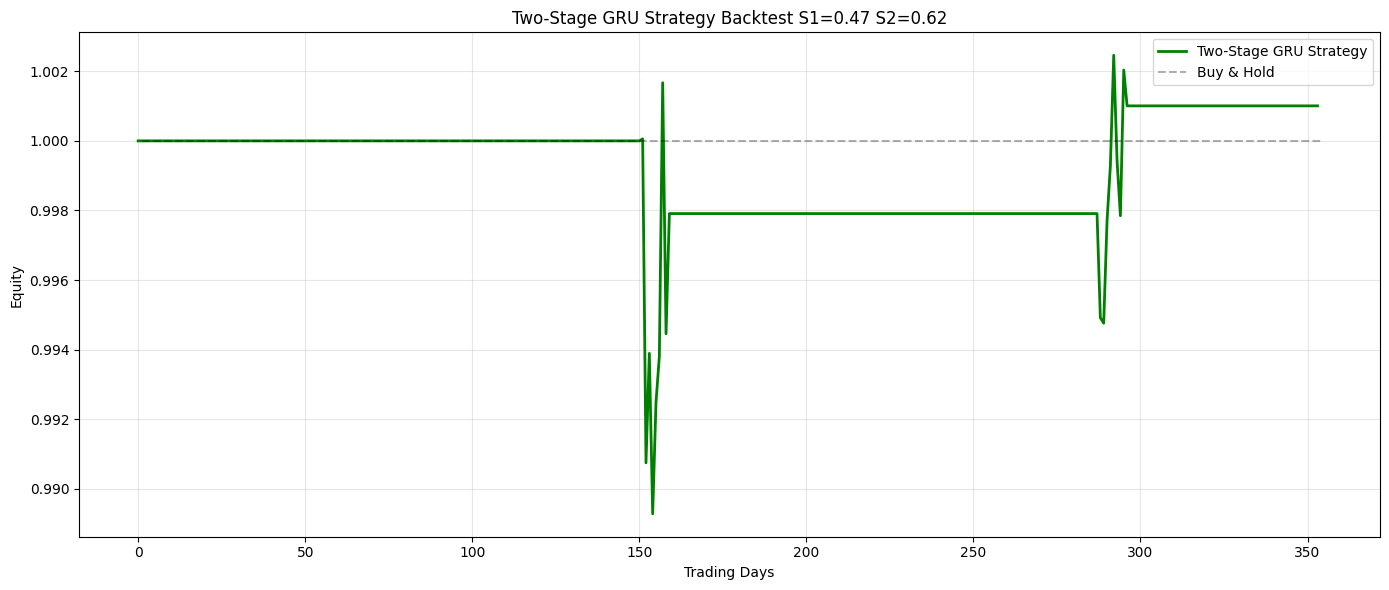

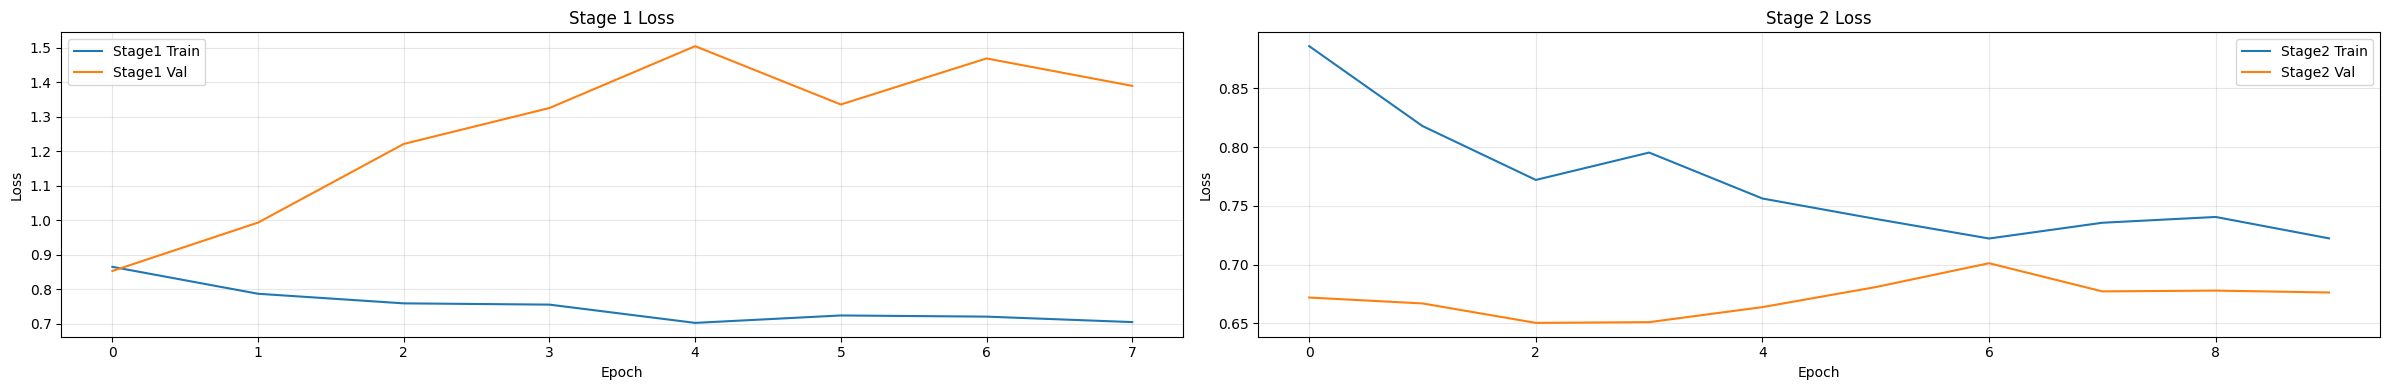

In [8]:
from sklearn.metrics import roc_auc_score

roc_auc_score(res_prepare_data['y1_test'], res_stage1['probs_test'])
roc_auc_score(res_stage2['y_true'], res_stage2['probs'])
probs_full = res_stage2['model'].predict(res_prepare_data['X_test']).flatten()

results = production_backtest(
    res_prepare_data['df_test'], 
    res_stage1['probs_test'], 
    probs_full,
    threshold1=res_stage1['threshold'], 
    threshold2=res_stage2['threshold'],
    commission=COMMISSION, 
    slippage=SLIPPAGE,
    max_position_size=MAX_POSITION_SIZE,
    horizon=HORIZON
)

# backtest с управлением капиталом и рисками
history_stages = [res_stage1['history'], res_stage2['history']]
thresholds = {"S1": res_stage1['threshold'], "S2": res_stage2['threshold']}
backtest(
    results=results,
    history_stages=history_stages,   
    strategy_name="Two-Stage GRU Strategy",
    thresholds=thresholds,
    save_dir="../models/model_gru"              
)


In [9]:
# Сохранение модели, scaler и параметров
params = {
    'threshold_stage1': res_stage1['threshold'],
    'threshold_stage2': res_stage2['threshold'],
    'move_threshold': MOVE_THRESHOLD,
    'horizon': HORIZON,
    'commission': COMMISSION,
    'slippage': SLIPPAGE,
    'max_position_size': MAX_POSITION_SIZE,
    'max_drawdown': MAX_DRAWDOWN,
    'sequence_length': SEQUENCE_LENGTH
}

backtest_results = {
    "total_return": results['total_return'],
    "sharpe_ratio": results['sharpe'],
    "max_drawdown": results['max_drawdown'],
    "win_rate": results['win_rate'],
    "trades": results['trades'],
    "avg_pnl": results['avg_pnl']
}

save_artifacts_json(
    base_dir=MODEL_PATH,
    strategy_name="two_stage",
    res_stage1=res_stage1,
    res_stage2=res_stage2,
    FEATURES=FEATURES,
    params=params,
    backtest_results=backtest_results
)

save_models(
    model_stage1=res_stage1['model'],
    model_stage2=res_stage2['model'],
    scaler=res_prepare_data['scaler'],
    params=params,
    base_dir=MODEL_PATH,
    features=FEATURES
)

generate_final_report(
    results=results,
    model_type="two_stage",
    stage1_metrics={
        "threshold": res_stage1['threshold'],
        "f1": res_stage1['f1_val']
    },
    stage2_metrics={
        "threshold": res_stage2['threshold'],
        "f1": res_stage2['f1_val']
    },
    ml_metrics={
        "Stage 1 F1": res_stage1['f1_val'],
        "Stage 2 F1": res_stage2['f1_val']
    }
)

✅ JSON summary saved: ../models/model_gru/two_stage/artifacts_summary.json
✅ Model Stage 1 saved: ../models/model_gru/strategy/model_stage1.h5
✅ Model Stage 2 saved: ../models/model_gru/strategy/model_stage2.h5
✅ Scaler, features, and params (WITH features list) saved to ../models/model_gru/strategy

📁 Все артефакты сохранены в ../models/model_gru/strategy

📋 ИТОГОВЫЙ ОТЧЁТ

🎯 Two-Stage Classification:
   Stage 1: MOVE vs HOLD (Threshold=0.47000000000000003, F1=0.8750)
   Stage 2: UP vs DOWN (Threshold=0.6200000000000001, F1=0.8571)

Метрики:
   Stage 1 F1: 0.8750
   Stage 2 F1: 0.8571

💰 Production Backtest:
   Total Return: 0.1%
   Sharpe Ratio: 0.06
   Max Drawdown: 1.1%
Trades: 2
   Win Rate: 50.0%
